# Windowed MLP: a letter from 21 consecutive frames

Reads `PaulDataset-Metadata/paul-30mins.csv` and
`paul-training2` through `paul-training7` for training, and
`PaulDataset-Metadata/paul-val.csv` for testing, one row per frame.
Windows are built inside each capture, then concatenated, so a sample never
crosses from one video into the other.

Preprocessing, as in `experiment_mlp.ipynb`: unrotate by `deg`, mirror left hands onto
right, re-origin `world` on the wrist, min-max normalize each frame. No G/H/P/Q facing
correction, since this signer is filmed correctly.

A sample is frames `x-10 … x+10` concatenated, labelled by frame `x`. Training
drops centres whose window is incomplete or includes an unlabelled frame.
`paul-training6` then time-reverses each A–Y (except J) window — frames
`x+10 … x-10`, same centre label — so those letters have more unique windows
before `TRAIN_PER_CLASS`. `paul-training7` is J and Z only and is not reversed.
J, Z, and None are not reversed. Training then
balances to `TRAIN_PER_CLASS` windows per class. Sampled `None` windows are split
by `NONE_JZ_FRAC`: that share comes from None runs that touch a J or Z, the rest
from every other None. Validation repeats its first or last frame for
out-of-range offsets, drops any window that still includes an unlabelled frame,
then scores only centres with `palm >= PALM_MIN` and `presence >= PRESENCE_MIN`.


In [1]:
# --- Configuration ------------------------------------------------------------------
FEATURES = "2d+3d"      # "2d", "3d", or "2d+3d"
WINDOW = 10             # frames each side of the labelled one, so 21 per sample
HIDDEN = (512, 256, 128,64)
DROPOUT = 0.5
LR = 2e-5
BATCH_NORM = True
BATCH_SIZE = 256
EPOCHS = 100

PALM_MIN = 0.5          # frames below either gate go in as neutral
PRESENCE_MIN = 0.5      # 0 keeps every presence; 0.5 is jazz
NONE_JZ_FRAC = 0.5      # of sampled None, this share is J/Z-adjacent pauses
REVERSE_UPSAMPLE_CAPTURES = ("paul-training6",)  # time-reverse A–Y except J, before TRAIN_PER_CLASS

In [2]:
# --- Load the csvs and undo the ROI rotation -----------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd

TRAIN_CSVS = [
    Path("../PaulDataset-Metadata/paul-30mins.csv"),
    Path("../PaulDataset-Metadata/paul-training2.csv"),
    Path("../PaulDataset-Metadata/paul-training3.csv"),
    Path("../PaulDataset-Metadata/paul-training4.csv"),
    Path("../PaulDataset-Metadata/paul-training5.csv"),
    Path("../PaulDataset-Metadata/paul-training6.csv"),
    Path("../PaulDataset-Metadata/paul-training7.csv"),
]
VAL_CSV = Path("../PaulDataset-Metadata/paul-val.csv")
NODES = 21
CLASSES = [chr(c) for c in range(ord("A"), ord("Z") + 1)] + ["None"]


def read_capture(path):
    """One row per frame. keep_default_na=False, or "None" labels vanish as NaN."""
    df = pd.read_csv(path, keep_default_na=False)
    assert (np.diff(df["frame"].to_numpy()) == 1).all(), "windows need consecutive frames"
    deg = df["deg"].to_numpy(np.float32)

    def landmarks(group, axes):
        return np.stack([
            np.stack([df[f"{group}{node}_{axis}"].to_numpy(np.float32) for axis in axes], -1)
            for node in range(NODES)
        ], axis=1)

    def unrotate(points, centre):
        """Turn back by deg, about centre. z is the rotation axis and does not move."""
        rad = np.radians(deg)
        c, s = np.cos(rad), np.sin(rad)
        turn = np.stack([np.stack([c, -s], -1), np.stack([s, c], -1)], -2)
        out = points.copy()
        out[..., :2] = centre + np.einsum("nij,nkj->nki", turn, points[..., :2] - centre)
        return out

    return {
        "labels": df["label"].to_numpy(str),
        "handed_raw": df["handed_raw"].to_numpy(np.float32),
        "palm": df["palm"].to_numpy(np.float32),
        "presence": df["presence"].to_numpy(np.float32),
        "kp": unrotate(landmarks("kp", "xyz"), 0.5),
        "world": unrotate(landmarks("world", "xyz"), 0.0),
    }


train_caps = []
for path in TRAIN_CSVS:
    if not path.exists():
        print(f"skip missing {path.name}")
        continue
    cap = read_capture(path)
    cap["name"] = path.stem
    train_caps.append(cap)
    print(f"{path.stem:16} {len(cap['labels']):,} frames, "
          f"{int((cap['labels'] != '').sum()):,} labelled")
assert train_caps, "no training csvs found"
val_cap = read_capture(VAL_CSV)
print(f"{'paul-val':16} {len(val_cap['labels']):,} frames, "
      f"{int((val_cap['labels'] != '').sum()):,} labelled")


paul-30mins      54,130 frames, 54,130 labelled
paul-training2   24,257 frames, 24,257 labelled
paul-training3   18,016 frames, 14,372 labelled
paul-training4   24,432 frames, 24,432 labelled
paul-training5   23,434 frames, 23,434 labelled
paul-training6   86,378 frames, 86,378 labelled
paul-training7   36,064 frames, 0 labelled
paul-val         7,829 frames, 7,827 labelled


In [3]:
# --- One frame -> its feature block ---------------------------------------------------
FRAME_DIM = {"2d": 42, "3d": 63, "2d+3d": 105}[FEATURES]


def normalize(values):
    """Each frame's values to [0,1]. A frame with no spread becomes a neutral 0.5."""
    flat = values.reshape(len(values), -1)
    low = flat.min(1, keepdims=True)
    width = flat.max(1, keepdims=True) - low
    return np.divide(flat - low, width, out=np.full_like(flat, 0.5), where=width > 0)


def frame_features(cap):
    """Mirror left hands onto right, re-origin world, min-max, then gate by palm and presence."""
    left = cap["handed_raw"] < 0.5
    kp_fold, world_fold = cap["kp"].copy(), cap["world"].copy()
    kp_fold[left, :, 0] = 1.0 - kp_fold[left, :, 0]
    world_fold[left, :, 0] *= -1.0
    world_fold -= world_fold[:, :1, :]
    xy = normalize(kp_fold[..., :2])
    xyz = normalize(world_fold)
    per_frame = {"2d": xy, "3d": xyz, "2d+3d": np.concatenate([xy, xyz], 1)}[FEATURES]
    sure = (cap["palm"] >= PALM_MIN) & (cap["presence"] >= PRESENCE_MIN)
    per_frame = np.where(sure[:, None], per_frame, 0.5).astype(np.float32)
    return per_frame, sure, left


train_feats = []
train_left_all = []
train_sure_all = []
for cap in train_caps:
    feats, sure, left = frame_features(cap)
    train_feats.append(feats)
    train_left_all.append(left)
    train_sure_all.append(sure)
    print(f"{cap['name']:16} mirrored {left.mean():.1%}, {int((~sure).sum()):,} left neutral")
val_frame, val_sure, val_left = frame_features(val_cap)
train_left = np.concatenate(train_left_all)
train_sure = np.concatenate(train_sure_all)

print(f"{FEATURES!r} -> {FRAME_DIM} dims per frame")
print(f"train mirrored {train_left.mean():.1%}, {int((~train_sure).sum()):,} left neutral")
print(f"val   mirrored {val_left.mean():.1%}, {int((~val_sure).sum()):,} left neutral")


paul-30mins      mirrored 44.9%, 1,871 left neutral
paul-training2   mirrored 32.8%, 102 left neutral
paul-training3   mirrored 59.7%, 65 left neutral
paul-training4   mirrored 67.7%, 30 left neutral
paul-training5   mirrored 75.7%, 110 left neutral
paul-training6   mirrored 77.4%, 142 left neutral
paul-training7   mirrored 49.9%, 253 left neutral
'2d+3d' -> 105 dims per frame
train mirrored 60.8%, 2,573 left neutral
val   mirrored 5.6%, 1,178 left neutral


In [4]:
# --- Frames -> windows: x-10 … x+10, labelled by frame x ------------------------------
# Column k * FRAME_DIM + j is feature j of the frame k - WINDOW away from the label.
OFFSETS = np.arange(-WINDOW, WINDOW + 1)
IN_DIM = FRAME_DIM * len(OFFSETS)


def windows(per_frame, labels, repeat_edges=False):
    """Build centred windows. Unlabelled frames are never centres or inputs."""
    labelled = labels != ""
    centres = np.flatnonzero(labelled)
    if repeat_edges:
        frame_indices = np.clip(centres[:, None] + OFFSETS, 0, len(per_frame) - 1)
    else:
        centres = centres[(centres >= WINDOW) & (centres < len(per_frame) - WINDOW)]
        frame_indices = centres[:, None] + OFFSETS
    keep = labelled[frame_indices].all(1)
    centres = centres[keep]
    frame_indices = frame_indices[keep]
    X = per_frame[frame_indices].reshape(len(centres), IN_DIM)
    y = np.array([CLASSES.index(name) for name in labels[centres]], dtype=np.int64)
    return X, y, centres


def describe(name, y):
    counts = np.bincount(y, minlength=len(CLASSES))
    listed = "  ".join(f"{CLASSES[i]}={counts[i]}" for i in np.argsort(-counts) if counts[i])
    print(f"{name} y {y.shape}  {listed}")


def none_touching_jz(labels):
    """True on None frames whose run sits next to a J or a Z."""
    mask = np.zeros(len(labels), dtype=bool)
    if len(labels) == 0:
        return mask
    change = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    bounds = np.concatenate([[0], change, [len(labels)]])
    for start, end in zip(bounds[:-1], bounds[1:]):
        if labels[start] != "None":
            continue
        prev = labels[start - 1] if start else ""
        nxt = labels[end] if end < len(labels) else ""
        if prev in ("J", "Z") or nxt in ("J", "Z"):
            mask[start:end] = True
    return mask


# Training drops edge centres and any window that includes an unlabelled frame,
# per capture, then concatenates. A window never crosses from one video into
# another. paul-training6 then appends a time-reversed copy of each A–Y (except
# J) window so TRAIN_PER_CLASS can draw from a larger unique pool. J, Z, and
# None stay forward-only. Validation repeats its first/last frame so every
# labelled centre can get a full 21-frame window, then drops any window that
# still has a blank label.
REVERSE_SKIP = {CLASSES.index(name) for name in ("J", "Z", "None")}
train_X, train_y, train_jz = [], [], []
for cap, feats in zip(train_caps, train_feats):
    Xi, yi, centres = windows(feats, cap["labels"])
    print(f"{cap['name']:16} {len(yi):,} windows")
    if len(yi):
        jz = none_touching_jz(cap["labels"])[centres]
        if cap["name"] in REVERSE_UPSAMPLE_CAPTURES:
            keep = ~np.isin(yi, list(REVERSE_SKIP))
            Xr = np.ascontiguousarray(
                Xi[keep].reshape(-1, len(OFFSETS), FRAME_DIM)[:, ::-1]
            ).reshape(-1, IN_DIM)
            yr = yi[keep]
            print(f"{cap['name']:16} +{len(yr):,} reversed windows")
            Xi = np.concatenate([Xi, Xr])
            yi = np.concatenate([yi, yr])
            jz = np.concatenate([jz, np.zeros(len(yr), dtype=bool)])
        train_X.append(Xi)
        train_y.append(yi)
        train_jz.append(jz)
X = np.concatenate(train_X) if train_X else np.empty((0, IN_DIM), np.float32)
y = np.concatenate(train_y) if train_y else np.empty((0,), np.int64)
is_jz_none = np.concatenate(train_jz) if train_jz else np.zeros(0, dtype=bool)
print(f"None windows touching J/Z: {int(((y == CLASSES.index('None')) & is_jz_none).sum()):,}  "
      f"other None: {int(((y == CLASSES.index('None')) & ~is_jz_none).sum()):,}")
X_val, y_val, val_centres = windows(val_frame, val_cap["labels"], repeat_edges=True)
assert len(y_val), "paul-val has no labelled windows; label some frames first"

# Validation metrics use only samples whose labelled centre frame passes both gates.
assert len(val_centres) == len(y_val)
val_eval_mask = val_sure[val_centres]

print(f"{len(OFFSETS)} frames x {FRAME_DIM} dims -> {IN_DIM} inputs")
print(f"train X {X.shape}  {X.nbytes / 1e6:.0f} MB")
print(f"val   X {X_val.shape}  {X_val.nbytes / 1e6:.0f} MB")
print(f"val qualified centres {int(val_eval_mask.sum()):,} / {len(val_eval_mask):,}")
describe("train", y)
describe("val  ", y_val)


paul-30mins      54,110 windows
paul-training2   24,237 windows
paul-training3   14,352 windows
paul-training4   24,412 windows
paul-training5   23,414 windows
paul-training6   86,358 windows
paul-training6   +86,056 reversed windows
paul-training7   0 windows
None windows touching J/Z: 8,860  other None: 19,886
21 frames x 105 dims -> 2205 inputs
train X (312939, 2205)  2760 MB
val   X (7807, 2205)  69 MB
val qualified centres 6,629 / 7,807
train y (312939,)  None=28746  T=17173  S=14971  V=14896  E=13864  X=13774  A=13069  G=12930  D=12059  N=11405  U=11281  M=10876  L=10802  R=10765  B=10642  O=10612  Y=10538  C=10467  P=10403  K=10313  F=10290  W=10268  I=10265  H=10263  Q=10092  J=1365  Z=810
val   y (7807,)  None=814  U=342  Q=316  I=315  X=306  K=306  E=305  M=297  C=295  P=293  T=292  W=291  O=290  A=283  N=281  G=280  H=279  S=278  R=271  F=270  Y=269  B=267  L=251  V=246  D=240  J=75  Z=55


In [5]:
# --- Balance train to TRAIN_PER_CLASS windows per class -------------------------------
# Runs after reverse upsampling, so TRAIN_PER_CLASS draws from the enlarged pool.
# Subsample classes above the target; duplicate windows for classes below it.
# None is split: NONE_JZ_FRAC from pauses that touch J or Z, the rest from other Nones.
# paul-val remains untouched here and is filtered only when metrics are computed.
TRAIN_PER_CLASS = 20000
rng = np.random.default_rng(0)
NONE = CLASSES.index("None")


def take(idx, n):
    """n windows from idx, with replacement if the pool is smaller."""
    assert len(idx), "empty None pool"
    if len(idx) >= n:
        return rng.choice(idx, n, replace=False)
    extra = rng.choice(idx, n - len(idx), replace=True)
    return np.concatenate([idx, extra])


chosen = []
for cls in range(len(CLASSES)):
    idx = np.flatnonzero(y == cls)
    n = len(idx)
    assert n, f"no train windows for {CLASSES[cls]}"
    if cls == NONE:
        n_jz = int(round(TRAIN_PER_CLASS * NONE_JZ_FRAC))
        n_other = TRAIN_PER_CLASS - n_jz
        jz_idx = idx[is_jz_none[idx]]
        other_idx = idx[~is_jz_none[idx]]
        pick = np.concatenate([take(jz_idx, n_jz), take(other_idx, n_other)])
        print(f"None: {n_jz} from J/Z pauses ({len(jz_idx):,} available), "
              f"{n_other} from other Nones ({len(other_idx):,} available)")
    elif n >= TRAIN_PER_CLASS:
        pick = rng.choice(idx, TRAIN_PER_CLASS, replace=False)
    else:
        extra = rng.choice(idx, TRAIN_PER_CLASS - n, replace=True)
        pick = np.concatenate([idx, extra])
    chosen.append(pick)

order = rng.permutation(np.concatenate(chosen))
X, y = X[order], y[order]
counts = np.bincount(y, minlength=len(CLASSES))
assert len(y) == TRAIN_PER_CLASS * len(CLASSES)
assert np.all(counts == TRAIN_PER_CLASS), counts
print(f"train X {X.shape}  {X.nbytes / 1e6:.0f} MB")
describe("train", y)


None: 10000 from J/Z pauses (8,860 available), 10000 from other Nones (19,886 available)
train X (540000, 2205)  4763 MB
train y (540000,)  A=20000  Y=20000  X=20000  W=20000  V=20000  U=20000  T=20000  S=20000  R=20000  Q=20000  P=20000  O=20000  Z=20000  N=20000  L=20000  K=20000  J=20000  I=20000  H=20000  G=20000  F=20000  E=20000  D=20000  C=20000  B=20000  M=20000  None=20000


In [6]:
# --- Classifier ------------------------------------------------------------------------
import torch
import torch.nn as nn

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")


def build_mlp():
    layers, prev = [], IN_DIM
    for width in HIDDEN:
        layers.append(nn.Linear(prev, width))
        if BATCH_NORM:
            layers.append(nn.BatchNorm1d(width))
        layers += [nn.ReLU(), nn.Dropout(DROPOUT)]
        prev = width
    return nn.Sequential(*layers, nn.Linear(prev, len(CLASSES)))  # logits for the loss


def fresh():
    """An untrained model with a clean optimizer."""
    model = build_mlp().to(DEVICE)
    return model, torch.optim.Adam(model.parameters(), lr=LR)


criterion = nn.CrossEntropyLoss()
model, optimizer = fresh()

print(model)
print(f"{sum(t.numel() for t in model.parameters()):,} parameters on {DEVICE}")


Sequential(
  (0): Linear(in_features=2205, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=256, out_features=128, bias=True)
  (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.5, inplace=False)
  (12): Linear(in_features=128, out_features=64, bias=True)
  (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (14): ReLU()
  (15): Dropout(p=0.5, inplace=False)
  (16): Linear(in_features=64, out_features=27, bias=True)
)
1,305,627 parameters on mps


In [7]:
y

array([ 2, 17,  3, ...,  6, 12, 20], shape=(540000,))

train 540,000 windows; val 6,629 qualified windows of 7,807


train:   0%|          | 0/100 [00:00<?, ?ep/s]

  1  train loss 2.4588  acc 38.80%   val loss 1.9365  acc 71.31%
  5  train loss 0.5493  acc 88.60%   val loss 0.5520  acc 85.19%
 10  train loss 0.2370  acc 94.63%   val loss 0.4251  acc 86.59%
 15  train loss 0.1644  acc 96.13%   val loss 0.3711  acc 89.43%
 20  train loss 0.1331  acc 96.83%   val loss 0.4049  acc 89.32%
 25  train loss 0.1121  acc 97.30%   val loss 0.5038  acc 87.74%
 30  train loss 0.0987  acc 97.61%   val loss 0.4472  acc 89.27%
 35  train loss 0.0898  acc 97.79%   val loss 0.4291  acc 89.80%
 40  train loss 0.0817  acc 98.00%   val loss 0.4506  acc 89.88%
 45  train loss 0.0769  acc 98.13%   val loss 0.4183  acc 90.59%
 50  train loss 0.0712  acc 98.24%   val loss 0.4510  acc 90.15%
 55  train loss 0.0673  acc 98.34%   val loss 0.4544  acc 89.80%
 60  train loss 0.0642  acc 98.42%   val loss 0.4402  acc 90.27%
 65  train loss 0.0610  acc 98.48%   val loss 0.4347  acc 90.69%
 70  train loss 0.0583  acc 98.56%   val loss 0.4751  acc 90.10%
 75  train loss 0.0564  a

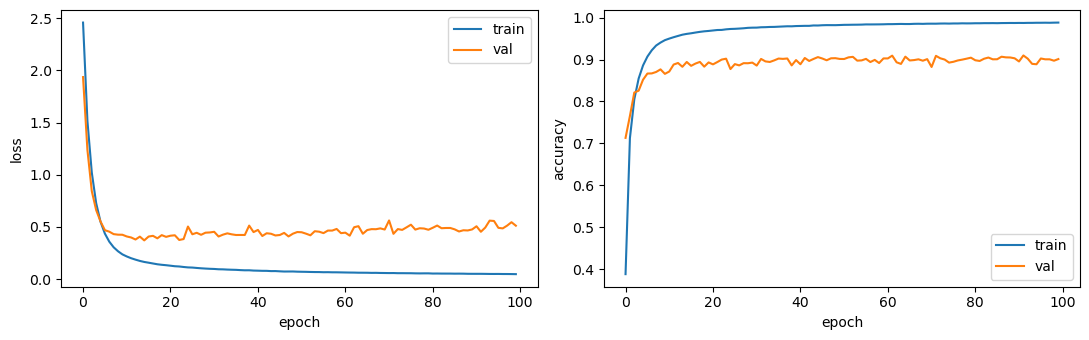

In [8]:
# --- Training -------------------------------------------------------------------------
# Every selected training window (paul-30mins + paul-training2..6) trains. Each epoch
# scores only paul-val windows
# whose labelled centre frame passes both gates, in eval mode (dropout off and
# BatchNorm running stats). Fresh weights every time this cell runs.
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CKPT = Path("weights") / f"window{WINDOW}_{FEATURES}_mlp.pt"
CKPT.parent.mkdir(exist_ok=True)

model, optimizer = fresh()
X_tr = torch.from_numpy(X).to(DEVICE)
y_tr = torch.from_numpy(y).to(DEVICE)
X_va = torch.from_numpy(X_val[val_eval_mask]).to(DEVICE)
y_va = torch.from_numpy(y_val[val_eval_mask]).to(DEVICE)
print(f"train {len(y_tr):,} windows; val {len(y_va):,} qualified windows "
      f"of {len(y_val):,}")


def run_epoch():
    """One shuffled pass over rows already on DEVICE -> mean loss, accuracy."""
    model.train(True)
    order = torch.randperm(len(y_tr), device=DEVICE)
    # Keep the final partial batch unless it has one row, which BatchNorm cannot use.
    if len(order) % BATCH_SIZE == 1:
        order = order[:-1]
    loss_sum = correct = 0.0
    for start in range(0, len(order), BATCH_SIZE):
        idx = order[start:start + BATCH_SIZE]
        logits = model(X_tr[idx])
        loss = criterion(logits, y_tr[idx])
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_sum += loss.detach() * len(idx)
        correct += (logits.argmax(1) == y_tr[idx]).sum()
    return (loss_sum / len(order)).item(), (correct / len(order)).item()


@torch.no_grad()
def evaluate():
    """Qualified-centre paul-val pass with dropout off and BatchNorm stats fixed."""
    model.eval()
    loss_sum = correct = 0.0
    n = len(y_va)
    for start in range(0, n, BATCH_SIZE):
        yb = y_va[start:start + BATCH_SIZE]
        logits = model(X_va[start:start + BATCH_SIZE])
        loss_sum += criterion(logits, yb) * len(yb)
        correct += (logits.argmax(1) == yb).sum()
    return (loss_sum / n).item(), (correct / n).item()


history = []
for epoch in tqdm(range(1, EPOCHS + 1), desc="train", unit="ep"):
    train_loss, train_acc = run_epoch()
    val_loss, val_acc = evaluate()
    history.append((train_loss, train_acc, val_loss, val_acc))
    if epoch == 1 or epoch % 5 == 0:
        print(f"{epoch:3d}  train loss {train_loss:.4f}  acc {train_acc:6.2%}"
              f"   val loss {val_loss:.4f}  acc {val_acc:6.2%}")

torch.save({"state_dict": model.state_dict(), "classes": CLASSES,
            "features": FEATURES, "window": WINDOW}, CKPT)
print(f"\nsaved {CKPT}")

hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, cols, name in zip(axes, ((0, 2), (1, 3)), ("loss", "accuracy")):
    ax.plot(hist[:, cols[0]], label="train")
    ax.plot(hist[:, cols[1]], label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(name)
    ax.legend()
plt.tight_layout()


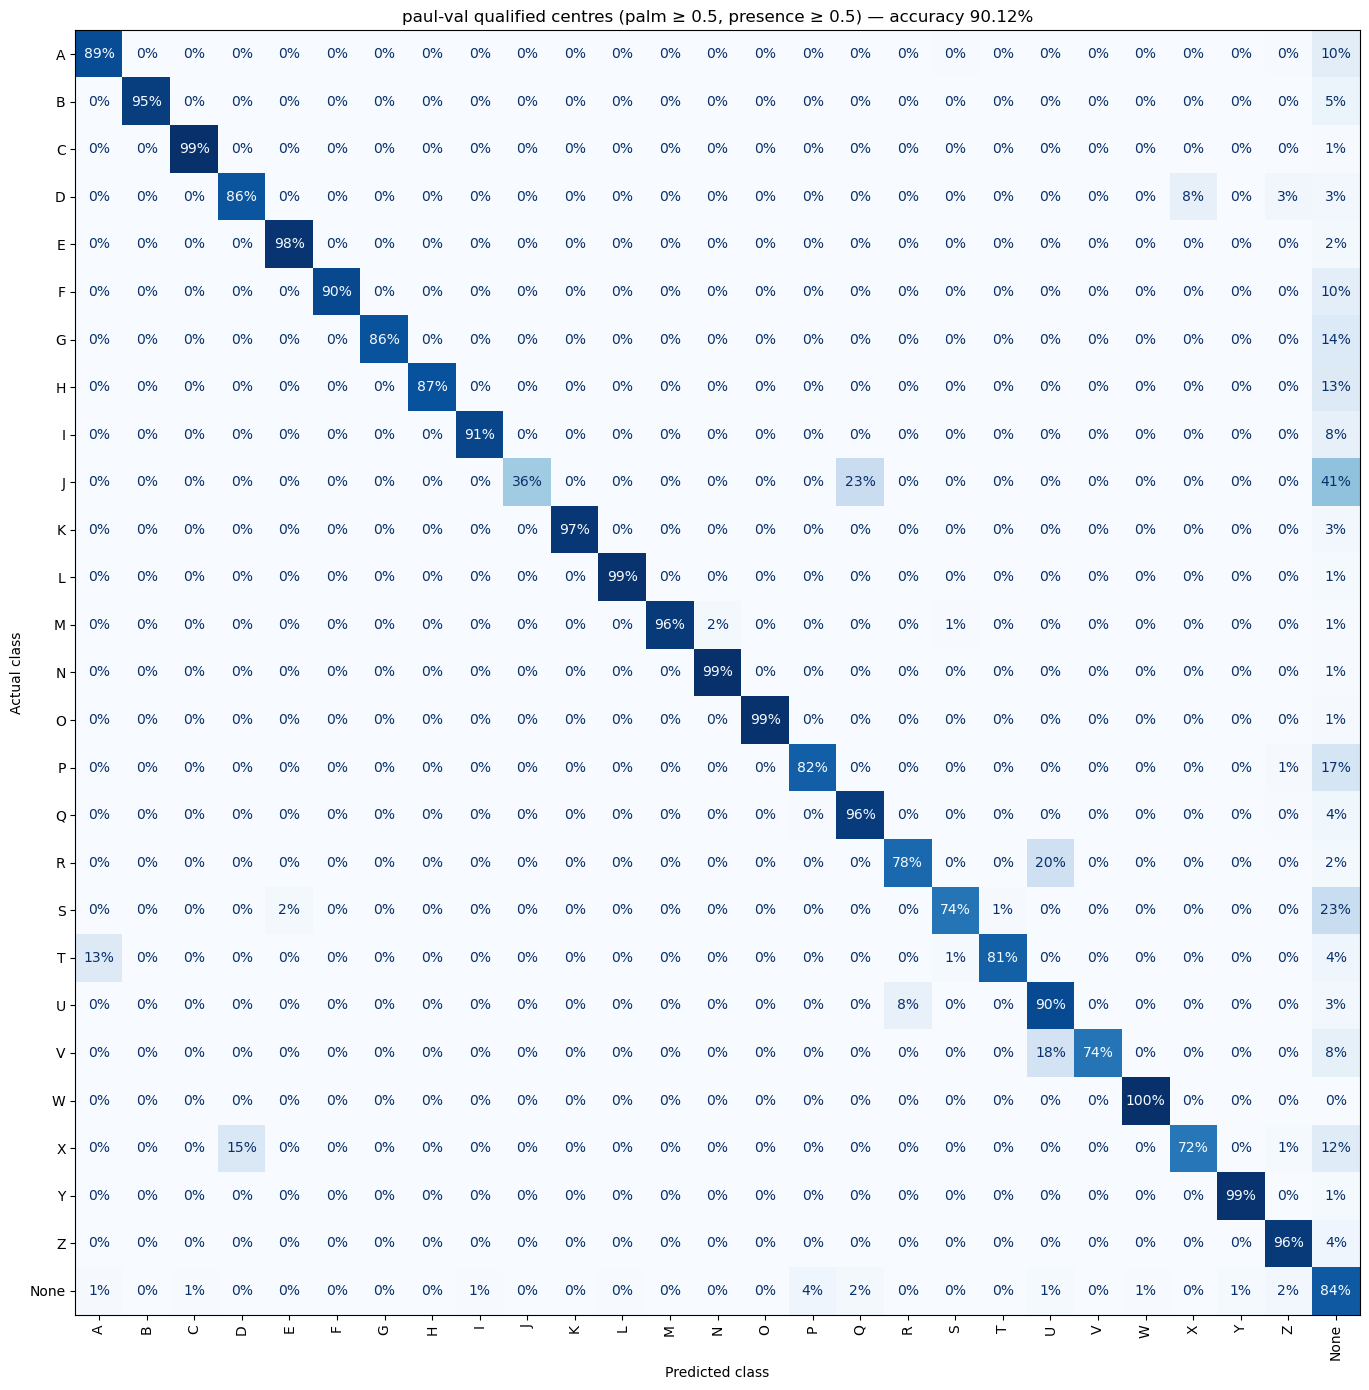

In [11]:
# --- Validation confusion matrix ------------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay

model.eval()
val_predictions = []
with torch.no_grad():
    for start in range(0, len(y_va), BATCH_SIZE):
        logits = model(X_va[start:start + BATCH_SIZE])
        val_predictions.append(logits.argmax(1).cpu())

y_val_true = y_va.cpu().numpy()
y_val_pred = torch.cat(val_predictions).numpy()
val_accuracy = (y_val_pred == y_val_true).mean()

fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    labels=np.arange(len(CLASSES)),
    display_labels=CLASSES,
    normalize="true",
    values_format=".0%",
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False,
    ax=ax,
)
ax.set_title(
    f"paul-val qualified centres (palm ≥ {PALM_MIN}, presence ≥ {PRESENCE_MIN}) "
    f"— accuracy {val_accuracy:.2%}"
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
plt.tight_layout()

In [13]:
# --- Export frame-by-frame validation predictions ------------------------------------
PREDICTIONS_CSV = VAL_CSV.with_name(f"{VAL_CSV.stem}-predictions.csv")

# The score and confusion matrix use qualified centres, but this report deliberately
# predicts every centre with a complete window.
model.eval()
val_probability_parts = []
with torch.no_grad():
    for start in range(0, len(X_val), BATCH_SIZE):
        X_batch = torch.from_numpy(X_val[start:start + BATCH_SIZE]).to(DEVICE)
        logits = model(X_batch)
        val_probability_parts.append(torch.softmax(logits, dim=1).cpu())

val_probabilities = torch.cat(val_probability_parts).numpy()
val_pred_indices = val_probabilities.argmax(axis=1)
val_pred_confidence = val_probabilities.max(axis=1)

# Map prediction rows back to centre frames from the window-building step.
# val_centres is smaller than "every labelled row": centres whose 21-frame window
# still includes a blank are dropped in windows().
assert len(val_centres) == len(val_pred_indices) == len(y_val)

val_source = pd.read_csv(VAL_CSV, keep_default_na=False)
val_report = val_source[["frame", "label"]].rename(columns={"label": "actual_label"})
val_report["predicted_label"] = ""
val_report["confidence"] = np.nan

val_report.loc[val_centres, "predicted_label"] = [
    CLASSES[index] for index in val_pred_indices
]
val_report.loc[val_centres, "confidence"] = val_pred_confidence
val_report["palm_confidence"] = val_source["palm"].to_numpy()
val_report["presence_confidence"] = val_source["presence"].to_numpy()

val_report.to_csv(PREDICTIONS_CSV, index=False)
print(f"saved {len(val_report):,} val frames to {PREDICTIONS_CSV}")
print(f"predictions: {len(val_centres):,}  (of {int((val_source['label'] != '').sum()):,} labelled)")
display(val_report.head(15))

saved 7,829 val frames to ../PaulDataset-Metadata/paul-val-predictions.csv
predictions: 7,807  (of 7,827 labelled)


,frame,actual_label,predicted_label,confidence,palm_confidence,presence_confidence
0,0,A,A,0.999968,0.67552,0.99661
1,1,A,A,0.999969,0.68731,0.99675
2,2,A,A,0.999970,0.61416,0.99591
3,3,A,A,0.999970,0.78678,0.99654
4,4,A,A,0.999968,0.79655,0.99595
5,5,A,A,0.999956,0.87044,0.99700
6,6,A,A,0.999925,0.86556,0.99702
7,7,A,A,0.999919,0.87201,0.99724
8,8,A,A,0.999903,0.85878,0.99771
9,9,A,A,0.999838,0.79894,0.99756
